<h1>CIFAR-10 - (Desne만 사용하기)</h1>
<br>
32 X 32 X 3의 해상도의 컬러 사물 데이터를 모아 놓은 데이터 세트다. CIFAR-10 데이터 세트는 총 10개의 클래스로 구성된다. 학습 데이터는 50,000개이고, 테스트 데이터는 10,000개다.<br>
Lable = <b>[airplane, automobile, bird, cat,deer, dog, frog, horse, ship, truck]</b>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

(x_train, y_train),(x_test, y_test) = cifar10.load_data()
print(x_train.shape) # (50000, 32, 32, 3) -> 채널이 3 : 컬러
print(y_train.shape) # (50000, 1)
print(x_test.shape) # (10000, 32, 32, 3)
print(y_test.shape) # (10000, 1)

# print(x_train[0])
print(y_train[0]) # [6]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)
[6]


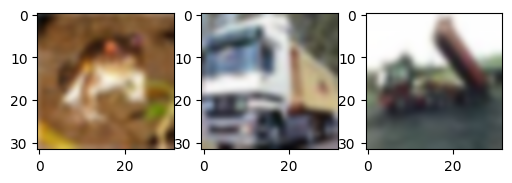

In [ ]:
# x_train[0] ~ 3 개 시각화
plt.figure(figsize=(6,2))
# plt.subplot(1, 3, 1)
plt.subplot(131)
plt.imshow(x_train[0], interpolation='bicubic') # interpolation :  보이는 모양의 형태
plt.subplot(132)
plt.imshow(x_train[1], interpolation='bicubic')
plt.subplot(133)
plt.imshow(x_train[2], interpolation='bicubic')
plt.show()

In [ ]:
# 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-Hot encoding(희소벡터 생성하기)
NUM_CLASSES = 10
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)
print(y_train[0])
# [6] => [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [ ]:
# 실습1) Sequential API CNN없는 Model 생성하기
model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=NUM_CLASSES, activation='softmax')
])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# 실습1-1) Function API CNN없는 Model 생성하기
input_layer = Input(shape=(32, 32, 3))
x = Flatten()(input_layer)
x = Dense(units=256, activation='relu')(x)
x = Dense(units=128, activation='relu')(x)
out_layer = Dense(units=NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=input_layer, outputs=out_layer)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# compile / fit
opti = Adam(learning_rate=0.001)
model.compile(
    loss='categorical_crossentropy',
    optimizer=opti,
    metrics=['accuracy']
)
model.fit(
    x=x_train, y=y_train, epochs=20, batch_size=128, validation_split=0.1, verbose=2, shuffle=True
)

# 모델 평가하기 (train, test평가 점수의 차이가 크면 overfitting 의심)
print(f'test acc :%.4f'%(model.evaluate(x_test, y_test, verbose=0, batch_size=128)[1]))
print(f'test loss :%.4f'%(model.evaluate(x_test, y_test, verbose=0, batch_size=128)[0]))

Epoch 1/20
352/352 - 6s - 16ms/step - accuracy: 0.3069 - loss: 1.9286 - val_accuracy: 0.3282 - val_loss: 1.8645
Epoch 2/20
352/352 - 1s - 4ms/step - accuracy: 0.3839 - loss: 1.7206 - val_accuracy: 0.3816 - val_loss: 1.7008
Epoch 3/20
352/352 - 1s - 3ms/step - accuracy: 0.4105 - loss: 1.6446 - val_accuracy: 0.4242 - val_loss: 1.6219
Epoch 4/20
352/352 - 1s - 3ms/step - accuracy: 0.4338 - loss: 1.5871 - val_accuracy: 0.4408 - val_loss: 1.5651
Epoch 5/20
352/352 - 1s - 3ms/step - accuracy: 0.4527 - loss: 1.5359 - val_accuracy: 0.4330 - val_loss: 1.5993
Epoch 6/20
352/352 - 1s - 3ms/step - accuracy: 0.4642 - loss: 1.5048 - val_accuracy: 0.4484 - val_loss: 1.5599
Epoch 7/20
352/352 - 1s - 3ms/step - accuracy: 0.4709 - loss: 1.4797 - val_accuracy: 0.4590 - val_loss: 1.5101
Epoch 8/20
352/352 - 1s - 4ms/step - accuracy: 0.4824 - loss: 1.4532 - val_accuracy: 0.4760 - val_loss: 1.4756
Epoch 9/20
352/352 - 2s - 4ms/step - accuracy: 0.4897 - loss: 1.4325 - val_accuracy: 0.4460 - val_loss: 1.5304


In [ ]:
CLASSES = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# 예측하기
pred = model.predict(x_test)
pred = CLASSES[np.argmax(pred[:10], axis=-1)] # axis = 0:열방향, 1:행방향, -1:행단위 뒤에서 부터 처리(마지막 축을 의미)
actual = CLASSES[np.argmax(y_test[:10], axis=-1)]
print('예측값 :',pred)
print('실제값 :',actual)
print('분류 실패 수 :',np.sum(pred != actual))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
예측값 : ['cat' 'truck' 'airplane' 'ship' 'deer' 'frog' 'cat' 'frog' 'bird'
 'automobile']
실제값 : ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류 실패 수 : 6


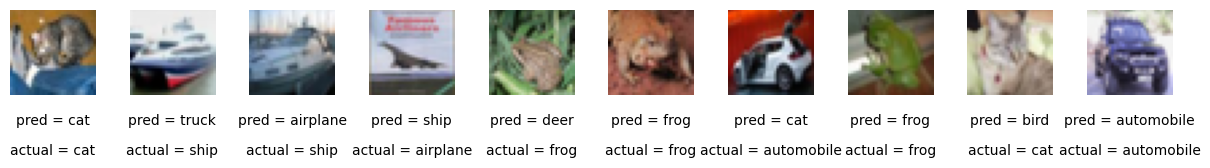

In [ ]:
# 시각화 하기
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4) # subplot사이 간격 조정

for i, idx in enumerate(range(len(x_test[:10]))):
    img = x_test[idx]
    ax = fig.add_subplot(1, len(x_test[:10]), i + 1)
    ax.axis('off')
    ax.imshow(img)

    # transform=ax.transAxes : 이미지 픽셀 좌표 대신에 subplot 영역 기준이다.
    # 0.5 : 가운데 정렬/ 0.0 : 왼쪽 정렬/ 1.0 : 오른쪽 정렬
    ax.text(0.5, -0.35, 'pred = '+str(pred[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.text(0.5, -0.7, 'actual = '+str(actual[idx]), fontsize=10, ha='center', transform=ax.transAxes)
plt.show()

# 현재 모델은 칼라 이미지 분류에 대한 정확도가 떨어짐. <- Dense만 사용